In [1]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.losses import BinaryCrossentropy

# Load Dataset

In [3]:
data = sns.load_dataset("titanic")

In [4]:
print(data.head())

   survived  pclass     sex   age  ...  deck  embark_town  alive  alone
0         0       3    male  22.0  ...   NaN  Southampton     no  False
1         1       1  female  38.0  ...     C    Cherbourg    yes  False
2         1       3  female  26.0  ...   NaN  Southampton    yes   True
3         1       1  female  35.0  ...     C  Southampton    yes  False
4         0       3    male  35.0  ...   NaN  Southampton     no   True

[5 rows x 15 columns]


In [6]:
# print column names and data types
print("\nColumns and Data Types:")
print(data.info())


Columns and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [7]:
# shape (rows, columns)
print("Shape of the dataset: \n")
print(data.shape)

Shape of the dataset: 

(891, 15)


In [8]:
data = data[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].dropna()

In [9]:
data['sex'] = data['sex'].map({'male':0, 'female':1})

In [10]:
data['embarked'] = data['embarked'].map({'S':0, 'C':1, 'Q':2})

In [14]:
X = data.drop("survived", axis=1).values.astype(np.float32)
y = data["survived"].values.reshape(-1, 1).astype(np.float32)

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Model

In [34]:
model_adam = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [35]:
# Model Compilation
model_adam.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [36]:
history_adam = model_adam.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, verbose=1)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6325 - loss: 0.6694 - val_accuracy: 0.6916 - val_loss: 0.6748
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6325 - loss: 0.6756 - val_accuracy: 0.6822 - val_loss: 0.6699
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6165 - loss: 0.6708 - val_accuracy: 0.6822 - val_loss: 0.6645
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6345 - loss: 0.6640 - val_accuracy: 0.7009 - val_loss: 0.6590
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6406 - loss: 0.6591 - val_accuracy: 0.7009 - val_loss: 0.6542
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6667 - loss: 0.6466 - val_accuracy: 0.7103 - val_loss: 0.6494
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6526 - loss: 0.6520 - val_accuracy: 0.7103 - val_loss: 0.6448
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6546 - loss: 0.6397 - val_accuracy: 0.7196 - v

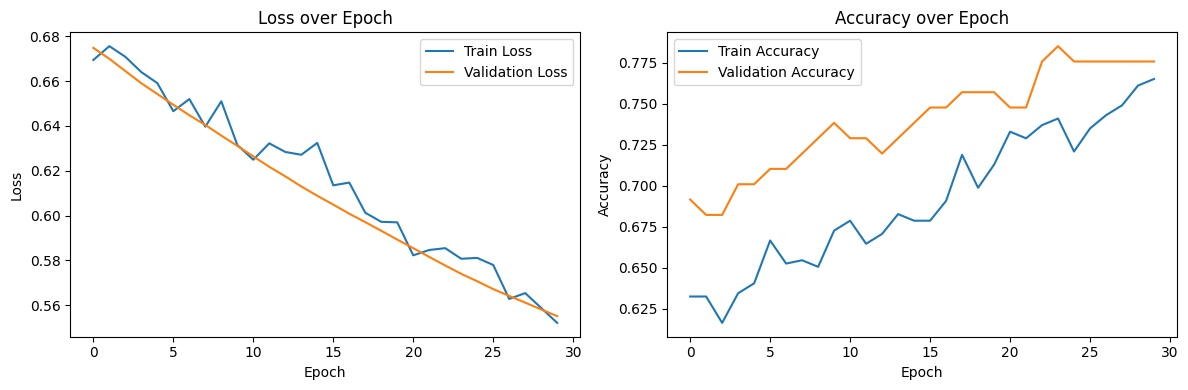

In [37]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['loss'], label='Train Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
y_test_pred_prob = model_adam.predict(X_test)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

acc_adam = accuracy_score(y_test, y_test_pred)
prec_adam = precision_score(y_test, y_test_pred)
rec_adam = recall_score(y_test, y_test_pred)
f1_adam = f1_score(y_test, y_test_pred)

print(f"Test Accuracy: {acc_adam}")
print(f"Test Precision: {prec_adam}")
print(f"Test Recall: {rec_adam}")
print(f"Test F1 Score: {f1_adam}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Test Accuracy: 0.7102803738317757
Test Precision: 0.7317073170731707
Test Recall: 0.6
Test F1 Score: 0.6593406593406593


In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix Adam")
plt.show()

SGD Model

In [40]:
model_sgd = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [41]:
# Model Compilation
model_sgd.compile(optimizer=SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

In [43]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [44]:
history_sgd = model_sgd.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32, callbacks=[early_stop], verbose=1)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4538 - loss: 0.8526 - val_accuracy: 0.4953 - val_loss: 0.8221
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4398 - loss: 0.7930 - val_accuracy: 0.5234 - val_loss: 0.7650
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5241 - loss: 0.7487 - val_accuracy: 0.5888 - val_loss: 0.7236
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6024 - loss: 0.7180 - val_accuracy: 0.6729 - val_loss: 0.6910
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6426 - loss: 0.6965 - val_accuracy: 0.7009 - val_loss: 0.6635
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6767 - loss: 0.6770 - val_accuracy: 0.7196 - val_loss: 0.6408
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7028 - loss: 0.6591 - val_accuracy: 0.7477 - val_loss: 0.6215
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7249 - loss: 0.6352 - val_accuracy: 0.7477 - v

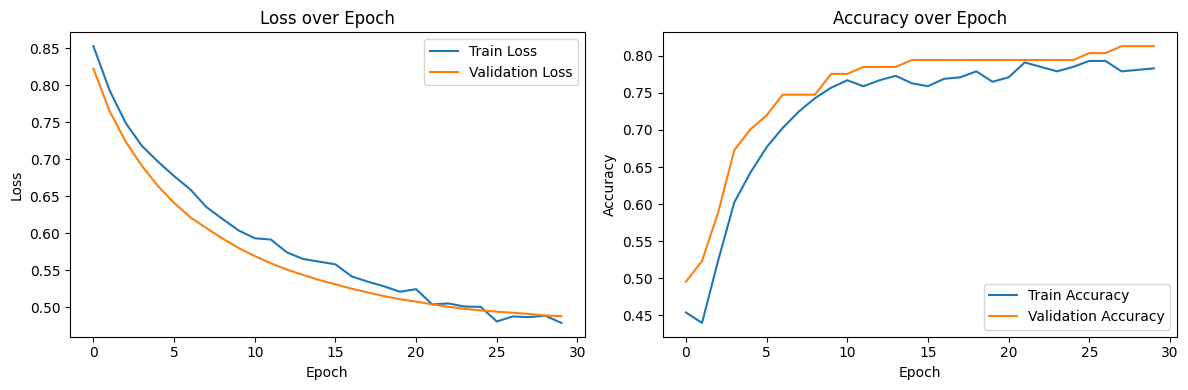

In [45]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['accuracy'], label='Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
y_test_pred_prob = model_sgd.predict(X_test)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

acc_sgd = accuracy_score(y_test, y_test_pred)
prec_sgd = precision_score(y_test, y_test_pred)
rec_sgd = recall_score(y_test, y_test_pred)
f1_sgd = f1_score(y_test, y_test_pred)

print(f"Test Accuracy: {acc_sgd}")
print(f"Test Precision: {prec_sgd}")
print(f"Test Recall: {rec_sgd}")
print(f"Test F1 Score: {f1_sgd}")

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Test Accuracy: 0.7289719626168224
Test Precision: 0.7142857142857143
Test Recall: 0.7
Test F1 Score: 0.7070707070707071


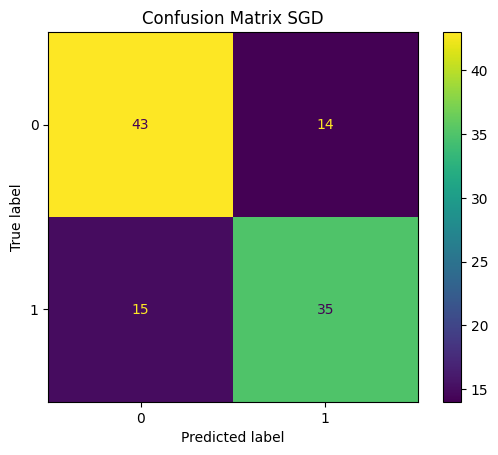

In [47]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix SGD")
plt.show()

# Hyperparameter Tuning

In [56]:
def build_model(hp):
  model = Sequential()
  model.add(Input(shape=(X_train.shape[1],)))
  model.add(Dense(hp.Int('units', min_value=16, max_value=128, step=16), activation='relu'))
  model.add(Dropout(hp.Float('dropout', 0.0, 0.5, step=0.1)))
  model.add(Dense(1, activation='sigmoid'))

  model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-2, 1e-3, 1e-4])), loss=BinaryCrossentropy(), metrics=['accuracy'])

  return model

In [57]:
tuner = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=10, executions_per_trial=1, directory='my_dir', project_name='hyperparameter_tuning')

tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32)

Trial 10 Complete [00h 00m 06s]
val_accuracy: 0.8130841255187988

Best val_accuracy So Far: 0.8504672646522522
Total elapsed time: 00h 01m 43s


In [58]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best n units: {best_hps.get('units')}")
print(f'Best dropout: {best_hps.get('dropout')}')
print(f"Best learning rate: {best_hps.get('lr')}")

Best n units: 64
Best dropout: 0.2
Best learning rate: 0.001


In [59]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32,
                         callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)], verbose=1)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5321 - loss: 0.7152 - val_accuracy: 0.6262 - val_loss: 0.6736
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6627 - loss: 0.6421 - val_accuracy: 0.6636 - val_loss: 0.6264
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7169 - loss: 0.5871 - val_accuracy: 0.7196 - val_loss: 0.5949
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7711 - loss: 0.5446 - val_accuracy: 0.7477 - val_loss: 0.5711
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7590 - loss: 0.5259 - val_accuracy: 0.7477 - val_loss: 0.5544
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7831 - loss: 0.4997 - val_accuracy: 0.7757 - val_loss: 0.5433
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7831 - loss: 0.4804 - val_accuracy: 0.7944 - val_loss: 0.5342
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8052 - loss: 0.4659 - val_accuracy: 0.7944 - val_lo

In [60]:
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {test_acc:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7757 - loss: 0.5177 
Test Accuracy: 0.7757


In [62]:
tuner.results_summary()

Results summary
Results in my_dir/hyperparameter_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
units: 64
dropout: 0.2
lr: 0.001
Score: 0.8504672646522522

Trial 08 summary
Hyperparameters:
units: 112
dropout: 0.0
lr: 0.001
Score: 0.8504672646522522

Trial 00 summary
Hyperparameters:
units: 128
dropout: 0.1
lr: 0.001
Score: 0.8317757248878479

Trial 02 summary
Hyperparameters:
units: 48
dropout: 0.0
lr: 0.01
Score: 0.8317757248878479

Trial 03 summary
Hyperparameters:
units: 48
dropout: 0.30000000000000004
lr: 0.001
Score: 0.822429895401001

Trial 06 summary
Hyperparameters:
units: 80
dropout: 0.4
lr: 0.01
Score: 0.822429895401001

Trial 09 summary
Hyperparameters:
units: 32
dropout: 0.2
lr: 0.01
Score: 0.8130841255187988

Trial 05 summary
Hyperparameters:
units: 96
dropout: 0.4
lr: 0.01
Score: 0.8037382960319519

Trial 01 summary
Hyperparameters:
units: 32
dropout: 0.2
lr: 0.0001
Score: 0.7289719581604004

Trial 04 summ

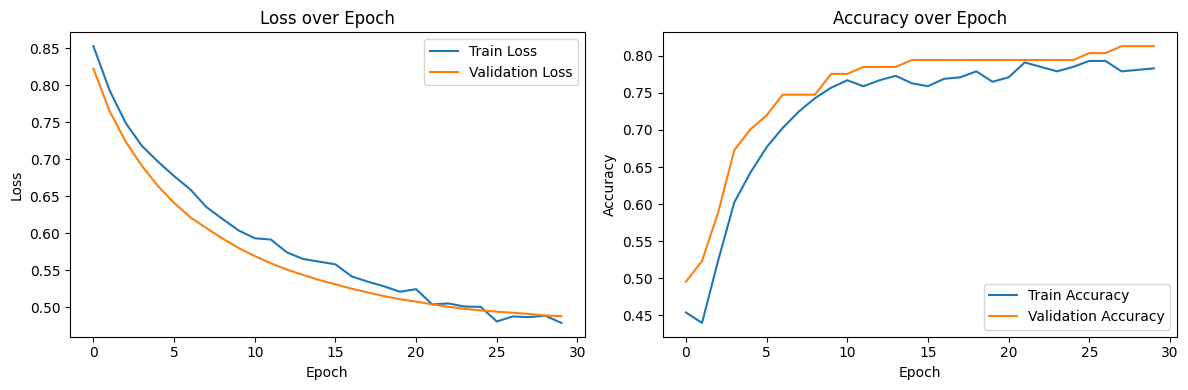

In [63]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['accuracy'], label='Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [64]:
y_test_pred_prob = best_model.predict(X_test)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Test Accuracy: {acc}")
print(f"Test Precision: {prec}")
print(f"Test Recall: {rec}")
print(f"Test F1 Score: {f1}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Test Accuracy: 0.7757009345794392
Test Precision: 0.782608695652174
Test Recall: 0.72
Test F1 Score: 0.75


In [65]:
results=[
    ['Adam', acc_adam, prec_adam, rec_adam, f1_adam],
    ['SDG', acc_sgd, prec_sgd, rec_sgd, f1_sgd],
    ['Tuner', acc, prec, rec, f1]
]

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Adam,0.710280,0.731707,0.60,0.659341
1,SDG,0.728972,0.714286,0.70,0.707071
2,Tuner,0.775701,0.782609,0.72,0.750000
